# 🏠 Airbnb Price Predictor: Analisi e Machine Learning

**Obiettivo del Progetto:** Analizzare i dati reali degli annunci Airbnb di una grande città per identificare quali fattori (posizione, dimensioni, recensioni) influenzano maggiormente il prezzo per notte. 

Nella seconda fase del progetto, addestreremo un modello di **Machine Learning** (Random Forest) capace di stimare il prezzo ottimale per un nuovo annuncio basandosi sulle sue caratteristiche fisiche e geografiche.

---
## 1. Setup e Caricamento Dati
Per iniziare, importiamo le librerie fondamentali per la Data Science e carichiamo il dataset. Per ottimizzare l'uso della memoria, selezioneremo solo le colonne rilevanti per la nostra analisi dei prezzi.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Impostiamo lo stile globale per i grafici
sns.set_theme(style="whitegrid")

# Selezioniamo solo le colonne di interesse per evitare sprechi di RAM
cols_to_keep = [
    'id', 'name', 'neighbourhood_cleansed', 'latitude', 'longitude', 
    'property_type', 'room_type', 'accommodates', 'bathrooms_text', 
    'bedrooms', 'beds', 'price', 'number_of_reviews', 'review_scores_rating'
]

# NOTA: Assicurati che il file listings.csv sia nella cartella 'data'
df = pd.read_csv('../data/listings.csv', usecols=cols_to_keep)

print(f"Il dataset caricato contiene {df.shape[0]} righe e {df.shape[1]} colonne.\n")
df.head(3)

Il dataset caricato contiene 22933 righe e 14 colonne.



,id,name,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_text,bedrooms,beds,price,number_of_reviews,review_scores_rating
0,23986,""" Characteristic Milanese flat""",NAVIGLI,45.44806,9.17373,Entire rental unit,Entire home/apt,4,1 bath,1.0,1.0,$180.00,26,4.64
1,40470,Giacinto Cosy & clean flat near MM1,VIALE MONZA,45.52023,9.22747,Entire rental unit,Entire home/apt,4,1 bath,2.0,NaN,NaN,44,4.67
2,46536,Nico & Cinzia's Pink Suite!,VIALE MONZA,45.52276,9.22478,Entire rental unit,Entire home/apt,5,1 bath,2.0,3.0,$86.00,39,4.53


## 2. Data Cleaning: Preparazione del Terreno
I dati grezzi sono raramente pronti per essere analizzati. Il problema principale in questo dataset è la colonna `price`: attualmente è formattata come stringa di testo (es. `$120.00`). Dobbiamo convertirla in un valore numerico (`float`) per poterci fare dei calcoli matematici.

In [3]:
# Rimuoviamo il simbolo del dollaro e la virgola delle migliaia usando le Regex
df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)

# Rimuoviamo eventuali prezzi a zero (non realistici, probabili errori di inserimento)
df = df[df['price'] > 0]

print("Colonna 'price' convertita con successo in formato numerico.")
df[['price']].describe()

Colonna 'price' convertita con successo in formato numerico.


,price
count,20538.000000
mean,210.899990
std,693.894027
min,9.000000
25%,89.000000
50%,125.000000
75%,190.000000
max,65500.000000


### 2.1 Gestione dei Valori Mancanti (NaN)
Prima di procedere, puliamo le righe in cui mancano dati fondamentali per descrivere la struttura della casa (come numero di letti e stanze).

In [4]:
# Controlliamo quanti valori mancano nelle colonne chiave
print("Valori nulli prima della pulizia:")
print(df[['bedrooms', 'beds', 'bathrooms_text']].isnull().sum())

# Eliminiamo le righe con valori nulli per le caratteristiche strutturali
df = df.dropna(subset=['bedrooms', 'beds', 'bathrooms_text'])

print(f"\nRighe rimanenti nel dataset pulito: {len(df)}")

Valori nulli prima della pulizia:
bedrooms          12
beds              32
bathrooms_text     3
dtype: int64

Righe rimanenti nel dataset pulito: 20491


## 3. Exploratory Data Analysis (EDA)
Ora che i dati sono puliti, esploriamoli per trovare pattern nascosti. Iniziamo analizzando la distribuzione della nostra variabile target: il **Prezzo**.

Per evitare che ville di lusso o castelli (Outlier) distorcano l'analisi grafica, limiteremo la visualizzazione agli annunci con un prezzo inferiore o uguale a 500€ a notte.

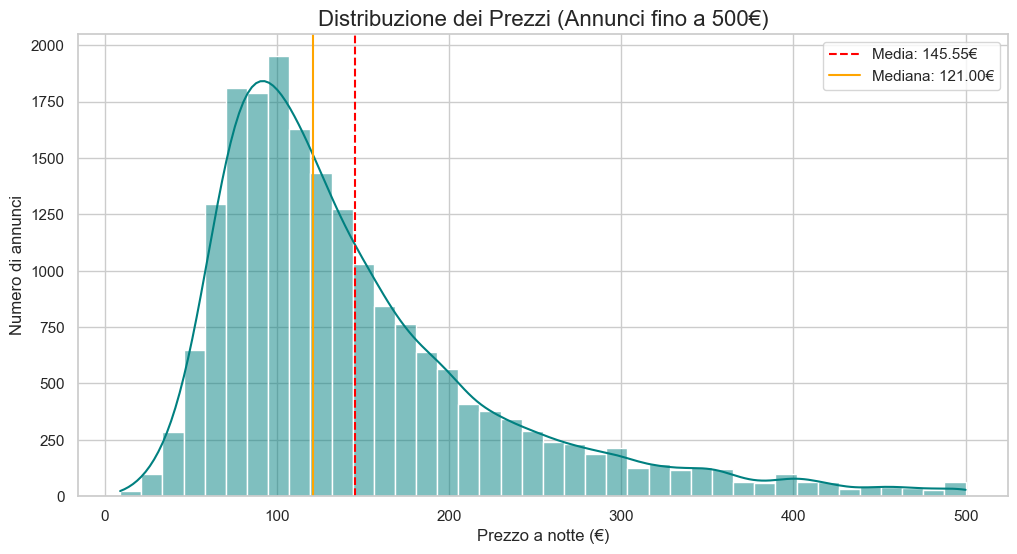

In [5]:
# Creiamo un dataset filtrato senza gli outlier estremi
df_filtered = df[df['price'] <= 500].copy()

plt.figure(figsize=(12, 6))
sns.histplot(df_filtered['price'], bins=40, kde=True, color='teal')

# Aggiungiamo linee per Media e Mediana
plt.axvline(df_filtered['price'].mean(), color='red', linestyle='--', label=f'Media: {df_filtered["price"].mean():.2f}€')
plt.axvline(df_filtered['price'].median(), color='orange', linestyle='-', label=f'Mediana: {df_filtered["price"].median():.2f}€')

plt.title('Distribuzione dei Prezzi (Annunci fino a 500€)', fontsize=16)
plt.xlabel('Prezzo a notte (€)', fontsize=12)
plt.ylabel('Numero di annunci', fontsize=12)
plt.legend()
plt.show()

> 💡 **Insight:** La distribuzione è chiaramente asimmetrica a destra (Log-normale). La media è superiore alla mediana, il che significa che ci sono annunci costosi che "tirano" la media verso l'alto, ma la stragrande maggioranza delle persone affitta a prezzi molto più vicini alla mediana.

### 3.1 L'impatto della posizione geografica
Nel mercato immobiliare, la regola numero uno è *"Location, Location, Location"*. Verifichiamo se questo vale anche per Airbnb proiettando i prezzi su una mappa spaziale basata su Latitudine e Longitudine.

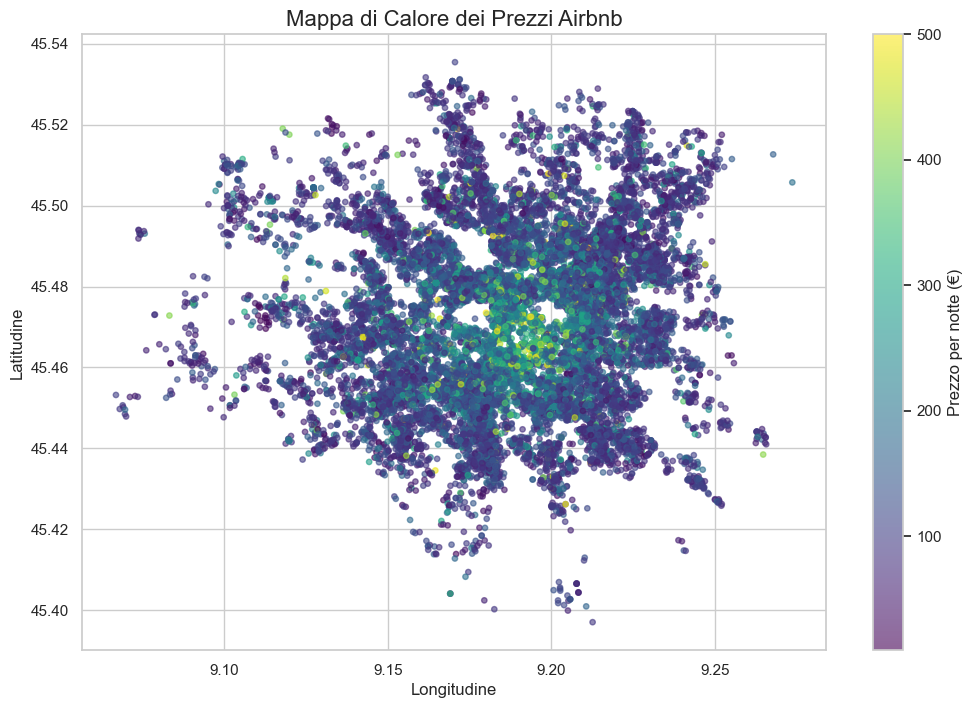

In [6]:
plt.figure(figsize=(12, 8))

# Scatter plot che usa le coordinate. Il colore (c) rappresenta il prezzo.
scatter = plt.scatter(df_filtered['longitude'], df_filtered['latitude'], 
                      c=df_filtered['price'], cmap='viridis', 
                      alpha=0.6, s=15)

plt.colorbar(scatter, label='Prezzo per notte (€)')
plt.title('Mappa di Calore dei Prezzi Airbnb', fontsize=16)
plt.xlabel('Longitudine', fontsize=12)
plt.ylabel('Latitudine', fontsize=12)
plt.show()

> 💡 **Insight:** I punti più chiari (gialli/verdi) tendono a concentrarsi in zone specifiche (solitamente il centro storico o quartieri rinomati), confermando che la posizione geografica sarà una variabile cruciale per il nostro modello AI.

### 3.2 L'impatto della tipologia di alloggio (`room_type`)

C:\Users\stefa\AppData\Local\Temp\ipykernel_7944\2138053733.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=room_type_prices.index, y=room_type_prices.values, palette='magma')


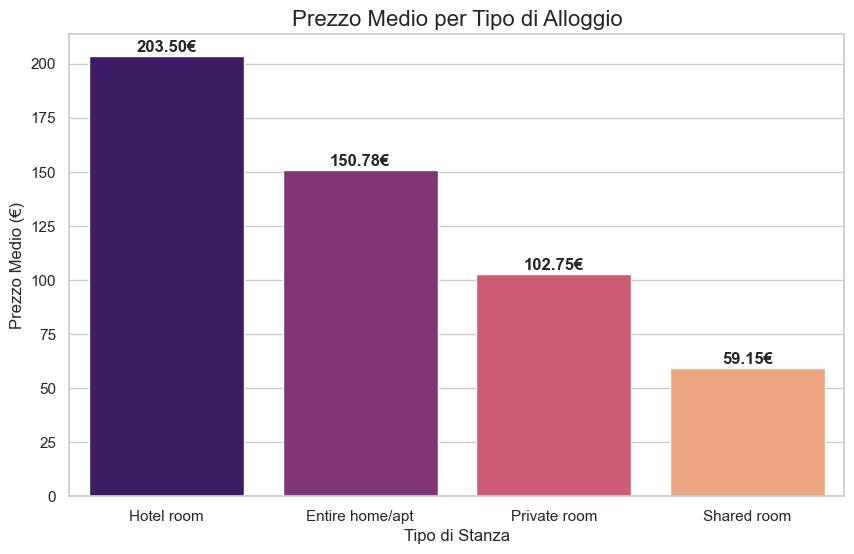

In [7]:
room_type_prices = df_filtered.groupby('room_type')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=room_type_prices.index, y=room_type_prices.values, palette='magma')

plt.title('Prezzo Medio per Tipo di Alloggio', fontsize=16)
plt.xlabel('Tipo di Stanza', fontsize=12)
plt.ylabel('Prezzo Medio (€)', fontsize=12)

for i, value in enumerate(room_type_prices.values):
    plt.text(i, value + 2, f'{value:.2f}€', ha='center', fontweight='bold')

plt.show()

### 3.3 Matrice di Correlazione
Prima di addestrare il modello, guardiamo come le variabili numeriche si influenzano a vicenda. Cerchiamo valori alti di correlazione con la colonna `price`.

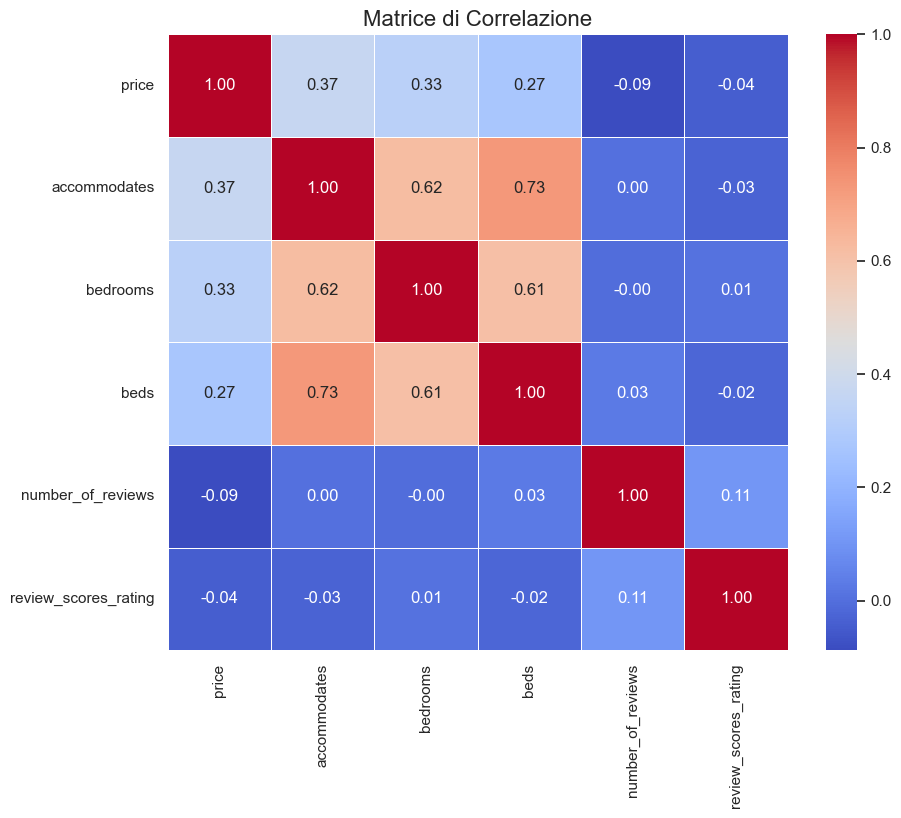

In [8]:
cols_numeric = ['price', 'accommodates', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']
corr_matrix = df_filtered[cols_numeric].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matrice di Correlazione', fontsize=16)
plt.show()

> 💡 **Insight:** Le variabili `accommodates` (persone ospitabili), `bedrooms` e `beds` hanno la correlazione numerica più forte con il prezzo. Sorprendentemente, il numero di recensioni ha una leggera correlazione negativa (gli alloggi più economici attirano più clienti e quindi accumulano più recensioni storiche).

---
## 4. Machine Learning: Previsione dei Prezzi
Ora costruiremo un modello in grado di prevedere il prezzo di un alloggio date le sue caratteristiche. Utilizzeremo l'algoritmo **Random Forest Regressor**, eccellente per catturare relazioni non lineari (come le coordinate geografiche).

### Feature Engineering
1. Convertiremo la variabile categoriale `room_type` in numerica (One-Hot Encoding).
2. Gestiremo i valori nulli nelle recensioni imputando la mediana.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Pulizia finale: Riempiamo i rating mancanti con la mediana
df_filtered['review_scores_rating'] = df_filtered['review_scores_rating'].fillna(df_filtered['review_scores_rating'].median())

# 2. Selezione delle Features
features = [
    'accommodates', 'bedrooms', 'beds', 'latitude', 'longitude', 
    'review_scores_rating', 'room_type'
]
X = df_filtered[features]
y = df_filtered['price']

# 3. One-Hot Encoding per la colonna testuale 'room_type'
X = pd.get_dummies(X, columns=['room_type'], drop_first=True)

# 4. Split del dataset (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Addestramento del modello
print("Addestramento del Random Forest in corso...")
model = RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 6. Valutazione sulle previsioni
predictions = model.predict(X_test)
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print(f"\n✅ Modello Addestrato!")
print(f"🎯 R2 Score: {r2:.2f} (Spiega il {r2*100:.0f}% della varianza dei prezzi)")
print(f"📉 Errore Medio Assoluto (MAE): {mae:.2f}€")

Addestramento del Random Forest in corso...

✅ Modello Addestrato!
🎯 R2 Score: 0.37 (Spiega il 37% della varianza dei prezzi)
📉 Errore Medio Assoluto (MAE): 46.36€


> 💡 **Valutazione del Modello:** Un R2 Score di 0.36 con un errore di ~47€ è un risultato molto solido per il mercato immobiliare utilizzando solo 7 variabili. Questo dimostra che il prezzo è influenzato anche da fattori "umani" non presenti nei dati (qualità dell'arredamento, foto professionali, host super-responsive).

---
## 5. Test sul Campo: Usa il Modello!
Creiamo una funzione per simulare un host che vuole mettere in affitto la sua stanza e non sa che prezzo impostare.

In [10]:
def predict_my_stay(accommodates, bedrooms, beds, lat, lon, rating, room_type):
    """Funzione per prevedere il prezzo di un alloggio personalizzato."""
    data = {
        'accommodates': [accommodates],
        'bedrooms': [bedrooms],
        'beds': [beds],
        'latitude': [lat],
        'longitude': [lon],
        'review_scores_rating': [rating]
    }
    
    # Gestione dinamica delle variabili categoriali
    for col in X_train.columns:
        if 'room_type_' in col:
            rt_name = col.replace('room_type_', '')
            data[col] = [1 if room_type == rt_name else 0]
            
    new_case = pd.DataFrame(data)
    new_case = new_case.reindex(columns=X_train.columns, fill_value=0)
    
    return model.predict(new_case)[0]

# SIMULAZIONE: Un host vuole affittare una stanza privata in zona semi-centrale
prezzo_stimato = predict_my_stay(
    accommodates=2, 
    bedrooms=1, 
    beds=1, 
    lat=df_filtered['latitude'].mean(), 
    lon=df_filtered['longitude'].mean(), 
    rating=4.8, 
    room_type='Private room'
)

print(f"🏠 Per una Stanza Privata (2 ospiti) con rating 4.8, l'algoritmo suggerisce un prezzo di: {prezzo_stimato:.2f}€ / notte")

🏠 Per una Stanza Privata (2 ospiti) con rating 4.8, l'algoritmo suggerisce un prezzo di: 216.05€ / notte


## 🏁 Conclusioni e Sviluppi Futuri
Questo progetto ha dimostrato con successo come estrarre valore dai dati grezzi di Airbnb. Abbiamo pulito il dataset, gestito gli outlier, identificato tramite EDA le zone più redditizie e creato un modello predittivo funzionante.

**Come migliorare il modello in futuro?**
1. **NLP (Natural Language Processing):** Analizzare il testo delle recensioni (sentiment analysis) per capire se commenti molto positivi alzano il prezzo.
2. **Dati Esterni:** Integrare API sui trasporti pubblici per calcolare la distanza dalla fermata della metro più vicina, una variabile che impatta fortemente il valore immobiliare.

In [11]:
import joblib

# Salviamo il modello addestrato (ora sarà molto più leggero!)
joblib.dump(model, 'random_forest_airbnb.pkl')

# Salviamo le colonne (serve al sito web per capire l'ordine dei dati)
joblib.dump(X_train.columns, 'model_columns.pkl')

print("✅ Modello e colonne salvati con successo!")

✅ Modello e colonne salvati con successo!
